In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

In [2]:
TITLE_FONTSIZE = 18

In [3]:
df = pd.read_csv("./tools_list.tsv", sep="\t")

# Make 'year' column an integer for rows that are not NaN
df["year"] = pd.to_numeric(df["year"], errors="coerce").dropna().astype(int)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

df.head(1)

,tool_name,category,subcategory,title,link,journal,country,year,programming_language,last_author,affiliation
0,LC-MS2Struct,Annotation,Molecular library retrieval,Joint structural annotation of small molecules...,https://www.nature.com/articles/s42256-022-005...,Nature Machine Intelligence,Finland,2022,Python,J Rousu,Aalto University


Count programming languages

In [4]:
# Ensure NaNs are treated as empty strings, then split by ',' and strip whitespace
languages = (
    df["programming_language"]
    .fillna("")
    .apply(lambda x: [lang.strip() for lang in x.split(",") if lang.strip()])
)

# Flatten the list of lists into a single list, skip 'jupyter notebook' entries (case-insensitive)
all_languages = [
    lang
    for sublist in languages
    for lang in sublist
    if "notebook" not in lang.strip().lower()
]

# Remove "Webserver" from all_languages
all_languages = [
    lang for lang in all_languages if "webserver" not in lang.strip().lower()
]

# Remove "Not specified" and "NA" (case-insensitive) from list before counting
filtered_languages = [
    lang
    for lang in all_languages
    if lang.strip().lower()
    not in {
        "not specified",
        "na",
        "shell",
        "sccs",
        "database",
        "tex",
        "cmake",
        "gui",
        "scss",
        "fortran",
        "rez",
        "makefile",
        "ejs",
        "less",
        "css",
        "standalone",
        "html",
    }
]
# Count occurrences of each programming language
language_counter = Counter(filtered_languages)

Count Journals

In [5]:
# Count journals, ignore NaNs and harmonize the journal name by lower-casing, then capitalize
journals = df["journal"].dropna().apply(lambda x: x.strip().lower().capitalize())


# Capitalize all single-word journal names, otherwise capitalize only the first word
def smart_capitalize(journal):
    journal = journal.strip()
    if " " not in journal:
        return journal.capitalize()
    return " ".join([word.capitalize() for word in journal.split()])


journals = df["journal"].dropna().apply(lambda x: smart_capitalize(x.lower()))

journal_counter = Counter(journals)

Count categories

In [6]:
# Count occurrences of each category, clean up NaNs and whitespace, print top 10
category_counter = Counter(
    df["category"]
    .dropna()
    .apply(lambda x: [cat.strip() for cat in str(x).split("/")])
    .explode()
)

# Remove "DL" from category_counter since it's a category that can be duplicated
category_counter = Counter({k: v for k, v in category_counter.items() if k != "DL"})
# Rename "Quality Control" to "QC"
category_counter["QC"] = category_counter.pop("Quality Control")


def merge_others_and_split(subcat):
    # Split by "/", strip whitespace for each part
    subcats = [s.strip() for s in subcat.split("/")]
    # Apply "Others" merging logic to each part
    res = []
    for s in subcats:
        if s.lower().startswith("others"):
            res.append("Others")
        else:
            res.append(s)
    return res


subcategory_counter = Counter(
    df["subcategory"].dropna().apply(merge_others_and_split).explode()
)

subcategory_counter = Counter(
    {k.replace("|", "/"): v for k, v in subcategory_counter.items()}
)

Count countries

In [7]:
country_counter = Counter(
    df["country"].dropna().apply(lambda x: x.strip())  # ignore NaNs
)

Get affiliation counts

In [8]:
affiliation_counter = Counter(df["affiliation"].dropna().apply(lambda x: x.strip()))

In [9]:
# custom_palette = [
#     "#CC9648",  # muted warm orange
#     "#65A7CC",  # soft sky blue
#     "#218469",  # matte teal
#     "#B36A9B",  # subdued magenta
#     "#D5CB67",  # dusty yellow
#     "#BC673B",  # earthy orange-red
#     "#8775D8",  # gentle violet
#     "#C64B87",  # matte pink
#     "#7B8C8E",  # elegant muted teal-gray
# ]

# Pastel
custom_palette = [
    "#5B8FA8",  # soft blue
    "#8EBFAF",  # pastel green
    "#C4A1C9",  # muted lilac
    "#E3C6A6",  # warm beige
    "#D28C8C",  # gentle rose
    "#A6B7D8",  # powder blue
    "#C9E3E0",  # pale aqua
    "#BFAF8F",  # taupe
    "#E8B4A0",  # soft coral
    "#B5C4A3",  # muted sage
]


# Define a dictionary to map long journal names to their acronyms
journal_acronyms = {
    "Journal Of The American Society For Mass Spectrometry": "J. Am. Soc.\nMass Spectrom.",
    # Add more as needed:
    "Analytical Chemistry": "Anal. Chem.",
    "Bioinformatics": "Bioinform.",
    "Journal Of Cheminformatics": "J. Chem. Inf. Model.",
    "Journal Of Proteome Research": "J. Proteome Res.",
    "Nature Communications": "Nat. Commun.",
    "Nucleic Acids Research": "Nucleic Acids Res.",
    "Bmc Bioinformatics": "BMC Bioin.",
    "Biorxiv": "bioRxiv",
    # Add more mappings as required
}


def map_journal_to_acronym(journal):
    return journal_acronyms.get(journal, journal)


# Make an acronym-mapped journal_counter for the plots
journal_counter_acronym = Counter()
for name, count in journal_counter.items():
    short = map_journal_to_acronym(name)
    journal_counter_acronym[short] += count


# Use first 5 for top items in pie, keeping a slot for "Other"
color_palette = custom_palette
other_color = "#E0E0E0"  # Color for "Other"


def prepare_pie_data(counter, top_n=5):
    """
    Prepare data for pie chart: top N items + "Other" category
    Merges "Other" and "Others" into a single "Other" category
    """
    # Handle if counter is a list of tuples (from most_common)
    if isinstance(counter, list):
        counter_dict = dict(counter)
    else:
        # It's a Counter object
        counter_dict = dict(counter)

    # Merge "Other" and "Others" if they exist
    merged_dict = {}
    other_count_merged = 0
    for key, value in counter_dict.items():
        # Handle non-string keys (e.g., NaN floats)
        if isinstance(key, str):
            key_clean = key.lower()
        else:
            key_clean = str(key).lower() if pd.notna(key) else ""
        if key_clean in ["other", "others"]:
            other_count_merged += value
        else:
            merged_dict[key] = value

    # If we found "Other" or "Others", add them as a single "Other" entry
    if other_count_merged > 0:
        merged_dict["Other"] = other_count_merged

    # Helper function to safely get cleaned key
    def get_key_clean(key):
        if isinstance(key, str):
            return key.lower()
        else:
            return str(key).lower() if pd.notna(key) else ""

    # Get top N, excluding "Other" from the top list
    sorted_items = sorted(merged_dict.items(), key=lambda x: x[1], reverse=True)
    # Filter out "Other" from top items
    top_items = [(k, v) for k, v in sorted_items[:top_n] if get_key_clean(k) != "other"]
    # Get "Other" if it exists and wasn't in top N
    other_item = [(k, v) for k, v in sorted_items if get_key_clean(k) == "other"]
    # Get remaining items (not in top and not "Other")
    remaining_items = [
        (k, v) for k, v in sorted_items[top_n:] if get_key_clean(k) != "other"
    ]

    # Calculate total "Other" count
    other_count = sum(v for _, v in other_item) + sum(v for _, v in remaining_items)

    # Prepare labels and sizes
    labels = [item[0] for item in top_items]
    sizes = [item[1] for item in top_items]

    if other_count > 0:
        labels.append("Other")
        sizes.append(other_count)

    return labels, sizes


def prepare_bar_data(counter, top_n=8):
    """
    Prepare data for bar chart: top N items by count.
    Merges 'Other'/'Others' entries.
    Returns (labels, counts) lists.
    """
    if isinstance(counter, list):
        counter_dict = dict(counter)
    else:
        counter_dict = dict(counter)

    merged_dict = {}
    other_count_merged = 0
    for key, value in counter_dict.items():
        if not isinstance(key, str):
            key_str = str(key) if pd.notna(key) else "(blank)"
        else:
            key_str = key
        key_clean = key_str.strip().lower()
        if key_clean in ["other", "others"]:
            other_count_merged += value
        else:
            merged_dict[key] = value
    if other_count_merged > 0:
        merged_dict["Other"] = other_count_merged

    sorted_items = sorted(merged_dict.items(), key=lambda x: x[1], reverse=True)

    def get_key_clean(key):
        if not isinstance(key, str):
            key_str = str(key) if pd.notna(key) else "(blank)"
        else:
            key_str = key
        return key_str.strip().lower()

    top_items = [
        item for item in sorted_items[:top_n] if get_key_clean(item[0]) != "other"
    ]

    labels = []
    for item in top_items:
        key = item[0]
        if isinstance(key, str):
            label = key if key.strip() != "" else "(blank)"
        elif pd.notna(key):
            label = str(key)
        else:
            label = "(blank)"
        labels.append(label)
    counts = [item[1] for item in top_items]
    return labels, counts


# Prepare data for time-series visualizations
# Filter out rows with missing years
df_with_year = df[df["year"].notna()].copy()

# 1. Distribution of tool categories across years (stacked bar chart)
category_year_data = []
for _, row in df_with_year.iterrows():
    year = row["year"]
    if pd.notna(row["category"]):
        categories = [cat.strip() for cat in str(row["category"]).split("/")]
        for cat in categories:
            if cat:  # Skip empty strings
                category_year_data.append({"year": year, "category": cat})

category_year_df = pd.DataFrame(category_year_data)
if len(category_year_df) > 0:
    category_year_counts = (
        category_year_df.groupby(["year", "category"]).size().unstack(fill_value=0)
    )
    # Get top categories
    top_categories = category_counter.most_common(8)
    top_category_names = [cat for cat, _ in top_categories]
    # Reindex to include all years and fill missing with 0
    all_years = sorted([int(y) for y in df_with_year["year"].dropna().unique()])
    category_year_counts = category_year_counts.reindex(all_years, fill_value=0)
    category_year_counts.index = category_year_counts.index.astype(int)
else:
    category_year_counts = pd.DataFrame()
    top_category_names = []

# 2. Programming languages used over time (line chart)
language_year_data = []
for _, row in df_with_year.iterrows():
    year = row["year"]
    if pd.notna(row["programming_language"]):
        languages = [
            lang.strip()
            for lang in str(row["programming_language"]).split(",")
            if lang.strip()
        ]
        for lang in languages:
            if "notebook" not in lang.lower():
                language_year_data.append({"year": year, "language": lang})

language_year_df = pd.DataFrame(language_year_data)
if len(language_year_df) > 0:
    language_year_counts = (
        language_year_df.groupby(["year", "language"]).size().unstack(fill_value=0)
    )
    # Get top languages
    top_languages = language_counter.most_common(6)
    top_language_names = [lang for lang, _ in top_languages]
    # Reindex to include all years
    all_years = sorted([int(y) for y in df_with_year["year"].dropna().unique()])
    language_year_counts = language_year_counts.reindex(all_years, fill_value=0)
    language_year_counts.index = language_year_counts.index.astype(int)
else:
    language_year_counts = pd.DataFrame()
    top_language_names = []

# 3. Growth of subcategories over time (stacked bar chart)
subcategory_year_data = []
for _, row in df_with_year.iterrows():
    year = row["year"]
    if pd.notna(row["subcategory"]):
        subcategory_year_data.append(
            {"year": year, "subcategory": str(row["subcategory"]).strip()}
        )

subcategory_year_df = pd.DataFrame(subcategory_year_data)
if len(subcategory_year_df) > 0:
    subcategory_year_counts = (
        subcategory_year_df.groupby(["year", "subcategory"])
        .size()
        .unstack(fill_value=0)
    )
    # Get top subcategories
    top_subcategories = subcategory_counter.most_common(8)
    top_subcategory_names = [subcat for subcat, _ in top_subcategories]
    # Reindex to include all years
    all_years = sorted([int(y) for y in df_with_year["year"].dropna().unique()])
    subcategory_year_counts = subcategory_year_counts.reindex(all_years, fill_value=0)
    subcategory_year_counts.index = subcategory_year_counts.index.astype(int)
else:
    subcategory_year_counts = pd.DataFrame()
    top_subcategory_names = []

## Figure 1: Journals, Affiliations, Countries

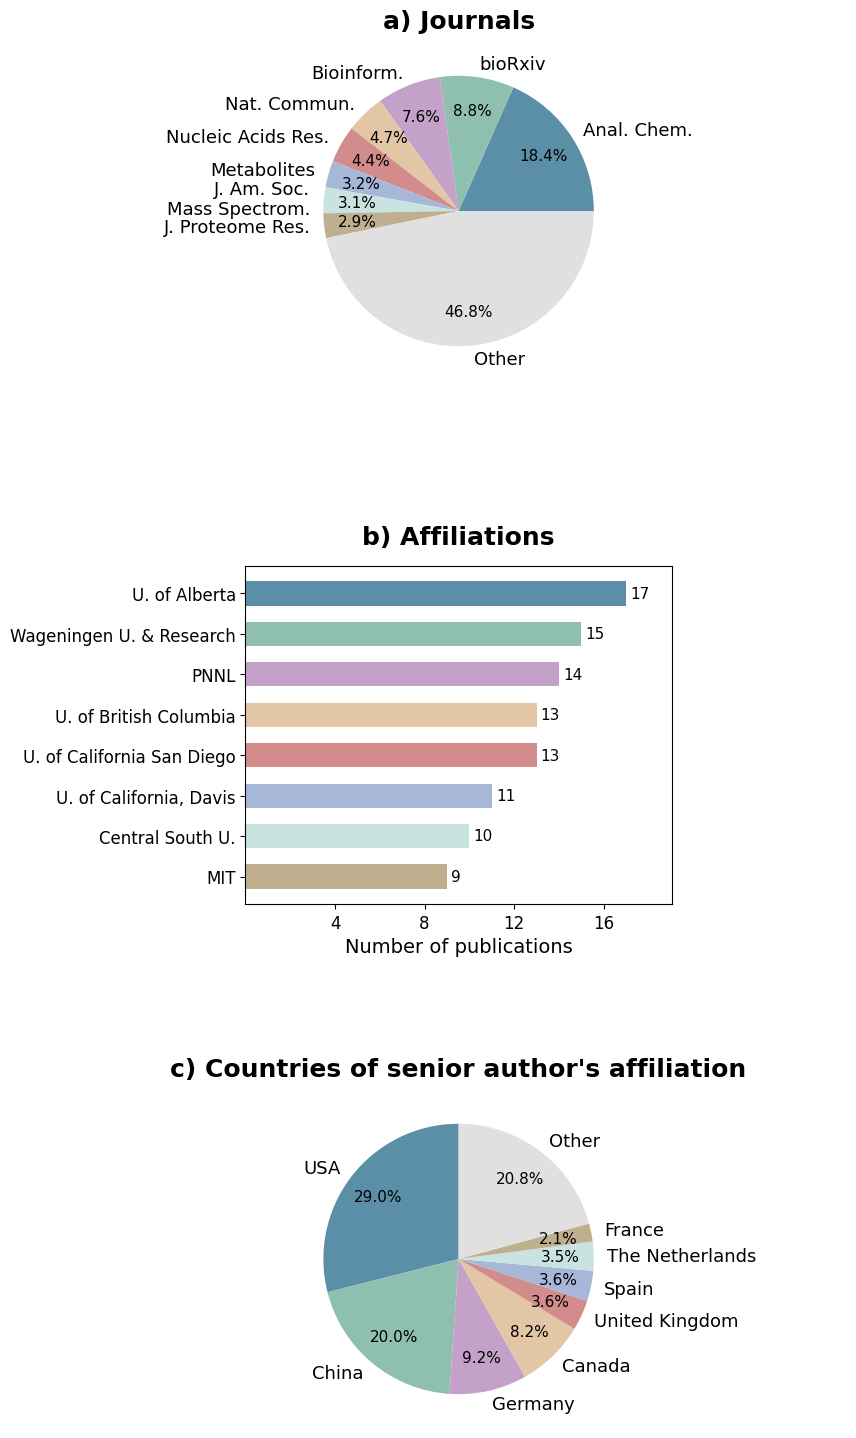

In [10]:
# Figure 1: a) Journals, b) Affiliations, c) Countries — vertical layout
fig1 = plt.figure(figsize=(10, 18))
gs1 = GridSpec(3, 1, figure=fig1, height_ratios=[1, 1, 1], hspace=0.55)
axes1 = [fig1.add_subplot(gs1[i]) for i in range(3)]

# a) Journals — pie chart
ax = axes1[0]
labels, sizes = prepare_pie_data(journal_counter_acronym, top_n=8)
n_top = len(labels) - (1 if "Other" in labels else 0)
colors = list(color_palette[:n_top])
if "Other" in labels:
    colors.append(other_color)
ax.set_title("a) Journals", fontsize=TITLE_FONTSIZE, fontweight="bold", pad=10)
ax.axis("equal")
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=0,
    colors=colors,
    textprops={"fontsize": 13},
    pctdistance=0.75,
    radius=1.0,
)
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(11)

# b) Affiliations — horizontal bar chart
ax = axes1[1]
aff_labels, aff_counts = prepare_bar_data(affiliation_counter, top_n=8)
# Shorten "University" to "U." in labels
aff_labels = [label.replace("University", "U.") for label in aff_labels]
aff_labels = [
    label.replace("Massachusetts Institute of Technology", "MIT")
    for label in aff_labels
]
aff_labels = [
    label.replace("Pacific Northwest National Laboratory", "PNNL")
    for label in aff_labels
]
bars = ax.barh(
    aff_labels,
    aff_counts,
    color=color_palette[: len(aff_labels)],
    height=0.6,
)
ax.set_ylabel("")
ax.set_xlabel("Number of publications", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="lower"))
ax.set_title("b) Affiliations", fontsize=TITLE_FONTSIZE, fontweight="bold", pad=16)
ax.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{int(width)}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
    )
ax.margins(x=0.12)
# Narrow the bar chart to match pie chart width
pos = ax.get_position()
new_width = pos.width * 0.55
new_x0 = pos.x0 + (pos.width - new_width) / 2
ax.set_position([new_x0, pos.y0, new_width, pos.height])

# c) Countries — pie chart
ax = axes1[2]
labels, sizes = prepare_pie_data(country_counter, top_n=8)
n_top = len(labels) - (1 if "Other" in labels else 0)
colors = list(color_palette[:n_top])
if "Other" in labels:
    colors.append(other_color)
ax.set_title(
    "c) Countries of senior author's affiliation",
    fontsize=TITLE_FONTSIZE,
    fontweight="bold",
    pad=10,
)
ax.axis("equal")
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 13},
    pctdistance=0.75,
    radius=1.0,
)
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(11)


fig1.savefig("figure1.png", dpi=400, bbox_inches="tight")
fig1.savefig("figure1.pdf", dpi=400, bbox_inches="tight")
plt.show()

## Figure 2: Programming Languages, Categories, Annotation Tool Types

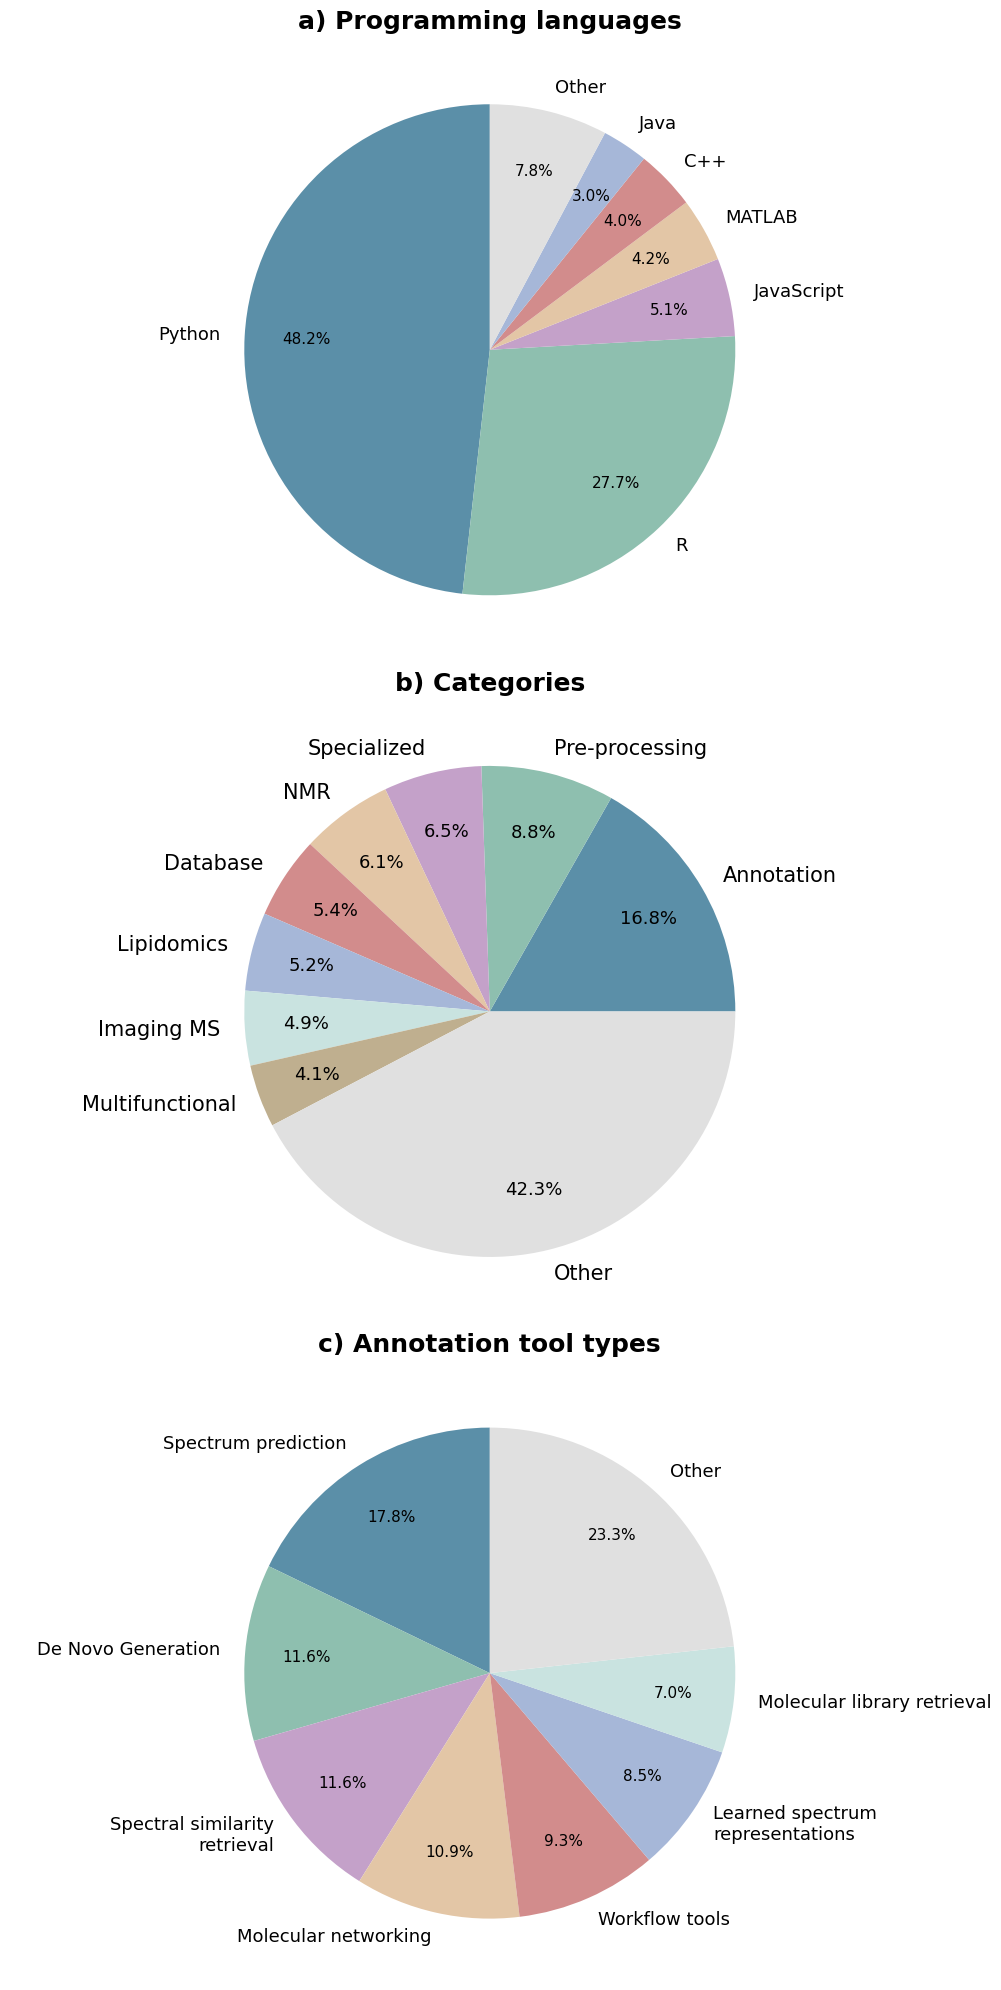

In [11]:
# Figure 2: a) Programming languages, b) Categories, c) Annotation tool types — vertical layout
fig2, axes2 = plt.subplots(3, 1, figsize=(10, 20))
plt.subplots_adjust(hspace=0.55)

# a) Programming languages — pie chart
ax = axes2[0]
labels, sizes = prepare_pie_data(language_counter, top_n=6)
n_top = len(labels) - (1 if "Other" in labels else 0)
colors = list(color_palette[:n_top])
if "Other" in labels:
    colors.append(other_color)
ax.set_title(
    "a) Programming languages", fontsize=TITLE_FONTSIZE, fontweight="bold", pad=10
)
ax.axis("equal")
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 13},
    pctdistance=0.75,
)
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(11)

# b) Categories — pie chart
ax = axes2[1]
labels, sizes = prepare_pie_data(category_counter, top_n=8)
n_top = len(labels) - (1 if "Other" in labels else 0)
colors = list(color_palette[:n_top])
if "Other" in labels:
    colors.append(other_color)
ax.set_title("b) Categories", fontsize=TITLE_FONTSIZE, fontweight="bold", pad=10)
ax.axis("equal")
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=0,
    colors=colors,
    textprops={"fontsize": 15},
    pctdistance=0.75,
)
for text in texts:
    text.set_fontsize(15)
for autotext in autotexts:
    autotext.set_fontsize(13)

# c) Annotation tool types — pie chart
ax = axes2[2]
labels, sizes = prepare_pie_data(subcategory_counter, top_n=8)
# Split long labels
labels = [
    label.replace(
        "Formula/class/property prediction",
        "Formula/class/property\nprediction",
    )
    for label in labels
]
labels = [
    label.replace(
        "Learned spectrum representations",
        "Learned spectrum\nrepresentations",
    )
    for label in labels
]
labels = [
    label.replace(
        "Spectral similarity retrieval",
        "Spectral similarity\nretrieval",
    )
    for label in labels
]
n_top = len(labels) - (1 if "Other" in labels else 0)
colors = list(color_palette[:n_top])
if "Other" in labels:
    colors.append(other_color)
ax.set_title(
    "c) Annotation tool types", fontsize=TITLE_FONTSIZE, fontweight="bold", pad=10
)
ax.axis("equal")
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 13},
    pctdistance=0.75,
)
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(11)

plt.tight_layout()
fig2.savefig("figure2.png", dpi=400, bbox_inches="tight")
fig2.savefig("figure2.pdf", dpi=400, bbox_inches="tight")
plt.show()

## Figure 3: Time Series and Citations (2x2)

/var/folders/6q/xdd_zynj36q_nl9dhb_0l72w0000gn/T/ipykernel_9341/2617541255.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


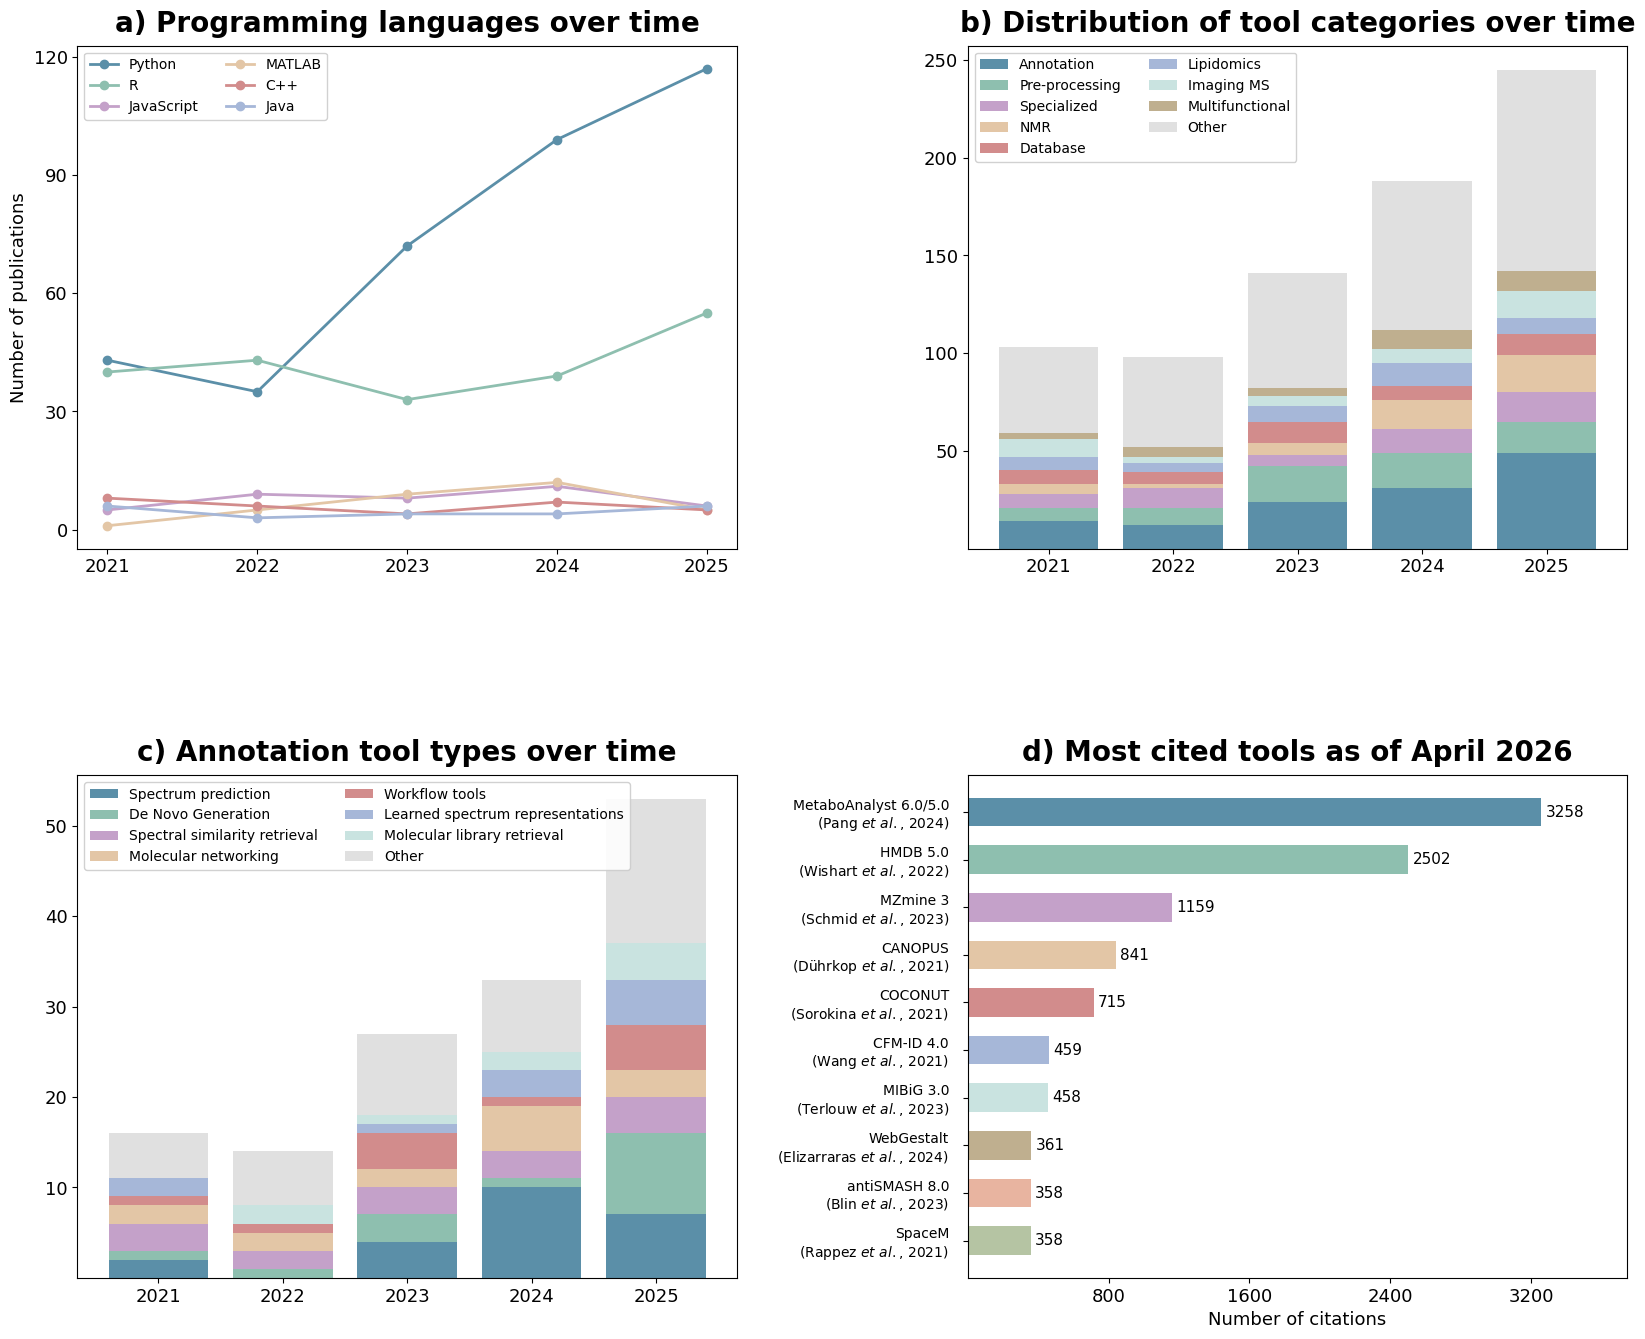

In [12]:
# Figure 3: a) Languages over time, b) Categories over time, c) Annotation types over time, d) Most cited — 2x2
fig3 = plt.figure(figsize=(20, 16))
gs3 = GridSpec(2, 2, figure=fig3, hspace=0.45, wspace=0.35)
axes3 = [fig3.add_subplot(gs3[r, c]) for r in range(2) for c in range(2)]

FIG3_TITLE_FONTSIZE = TITLE_FONTSIZE + 2
FIG3_TICK_LABELSIZE = 13

# a) Programming languages used over time (line chart)
ax = axes3[0]
if len(language_year_counts) > 0 and len(top_language_names) > 0:
    plot_languages = [
        lang for lang in top_language_names if lang in language_year_counts.columns
    ]
    for i, lang in enumerate(plot_languages):
        if lang in language_year_counts.columns:
            ax.plot(
                language_year_counts.index,
                language_year_counts[lang],
                marker="o",
                label=lang,
                linewidth=2,
                markersize=6,
                color=color_palette[i % len(color_palette)],
            )
    ax.set_title(
        "a) Programming languages over time",
        fontsize=FIG3_TITLE_FONTSIZE,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("", fontsize=13)
    ax.set_ylabel("Number of publications", fontsize=13)
    ax.legend(
        title="",
        fontsize=10,
        title_fontsize=11,
        loc="upper left",
        ncol=2,
        frameon=True,
        framealpha=0.9,
    )
    ax.tick_params(axis="x", labelsize=FIG3_TICK_LABELSIZE)
    ax.tick_params(axis="y", labelsize=FIG3_TICK_LABELSIZE)
    ax.set_xticks(language_year_counts.index)
    ax.set_xticklabels([int(x) for x in language_year_counts.index], rotation=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="lower"))

# b) Distribution of tool categories across years (stacked bar chart)
ax = axes3[1]
if len(category_year_counts) > 0 and len(top_category_names) > 0:
    plot_categories = [
        cat
        for cat in top_category_names
        if cat in category_year_counts.columns
        and cat.lower() not in ["other", "others"]
    ]
    other_cats = [
        cat for cat in category_year_counts.columns if cat not in plot_categories
    ]
    existing_other = [cat for cat in other_cats if cat.lower() in ["other", "others"]]
    excluded_from_top = [
        cat
        for cat in top_category_names
        if cat in category_year_counts.columns and cat.lower() in ["other", "others"]
    ]
    existing_other.extend(excluded_from_top)
    remaining_cats = [
        cat for cat in other_cats if cat.lower() not in ["other", "others"]
    ]
    all_other_cats = existing_other + remaining_cats

    plot_data = category_year_counts[plot_categories].copy()
    if len(all_other_cats) > 0:
        plot_data["Other"] = category_year_counts[all_other_cats].sum(axis=1)

    plot_colors = []
    color_idx = 0
    for col in plot_data.columns:
        if col == "Other":
            plot_colors.append(other_color)
        else:
            plot_colors.append(color_palette[color_idx % len(color_palette)])
            color_idx += 1

    plot_data.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=plot_colors,
        width=0.8,
    )
    ax.set_title(
        "b) Distribution of tool categories over time",
        fontsize=FIG3_TITLE_FONTSIZE,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("", fontsize=13)
    ax.set_ylabel("", fontsize=13)
    ax.legend(
        title="",
        fontsize=10,
        title_fontsize=11,
        loc="upper left",
        ncol=2,
        frameon=True,
        framealpha=0.9,
    )
    ax.tick_params(axis="x", labelrotation=0, labelsize=FIG3_TICK_LABELSIZE)
    ax.tick_params(axis="y", labelsize=FIG3_TICK_LABELSIZE)
    ax.set_xticklabels([int(x) for x in plot_data.index], rotation=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6, prune="lower"))

# c) Annotation tools subtypes over time (stacked bar chart)
ax = axes3[2]
if len(subcategory_year_counts) > 0 and len(top_subcategory_names) > 0:
    plot_subcategories = [
        subcat
        for subcat in top_subcategory_names
        if subcat in subcategory_year_counts.columns
        and subcat.lower() not in ["other", "others"]
    ]
    other_subcats = [
        subcat
        for subcat in subcategory_year_counts.columns
        if subcat not in plot_subcategories
    ]
    existing_other = [
        subcat for subcat in other_subcats if subcat.lower() in ["other", "others"]
    ]
    excluded_from_top = [
        subcat
        for subcat in top_subcategory_names
        if subcat in subcategory_year_counts.columns
        and subcat.lower() in ["other", "others"]
    ]
    existing_other.extend(excluded_from_top)
    remaining_subcats = [
        subcat for subcat in other_subcats if subcat.lower() not in ["other", "others"]
    ]
    all_other_subcats = existing_other + remaining_subcats

    plot_data = subcategory_year_counts[plot_subcategories].copy()
    if len(all_other_subcats) > 0:
        plot_data["Other"] = subcategory_year_counts[all_other_subcats].sum(axis=1)

    plot_colors = []
    color_idx = 0
    for col in plot_data.columns:
        if col == "Other":
            plot_colors.append(other_color)
        else:
            plot_colors.append(color_palette[color_idx % len(color_palette)])
            color_idx += 1

    plot_data.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=plot_colors,
        width=0.8,
    )
    ax.set_title(
        "c) Annotation tool types over time",
        fontsize=FIG3_TITLE_FONTSIZE,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("", fontsize=13)
    ax.set_ylabel("", fontsize=13)
    ax.legend(
        title="",
        fontsize=10,
        title_fontsize=11,
        loc="upper left",
        ncol=2,
        frameon=True,
        framealpha=0.9,
    )
    ax.tick_params(axis="x", labelrotation=0, labelsize=FIG3_TICK_LABELSIZE)
    ax.tick_params(axis="y", labelsize=FIG3_TICK_LABELSIZE)
    ax.set_xticklabels([int(x) for x in plot_data.index], rotation=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6, prune="lower"))

# d) Most cited tools (horizontal bar chart)
ax = axes3[3]
citation_tools = [
    "SpaceM\n(Rappez $\\it{et\\ al.}$, 2021)",
    "antiSMASH 8.0\n(Blin $\\it{et\\ al.}$, 2023)",
    "WebGestalt\n(Elizarraras $\\it{et\\ al.}$, 2024)",
    "MIBiG 3.0\n(Terlouw $\\it{et\\ al.}$, 2023)",
    "CFM-ID 4.0\n(Wang $\\it{et\\ al.}$, 2021)",
    "COCONUT\n(Sorokina $\\it{et\\ al.}$, 2021)",
    "CANOPUS\n(Dührkop $\\it{et\\ al.}$, 2021)",
    "MZmine 3\n(Schmid $\\it{et\\ al.}$, 2023)",
    "HMDB 5.0\n(Wishart $\\it{et\\ al.}$, 2022)",
    "MetaboAnalyst 6.0/5.0\n(Pang $\\it{et\\ al.}$, 2024)",
]
ax.yaxis.set_tick_params(pad=10)
citation_counts = [
    358,
    358,
    361,
    458,
    459,
    715,
    841,
    1159,
    2502,
    1812 + 1446,
]

bars = ax.barh(
    citation_tools,
    citation_counts,
    color=custom_palette[::-1],  # reverse the palette for a different order
    height=0.6,
)
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{int(width)}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
    )
ax.set_title(
    "d) Most cited tools as of April 2026",
    fontsize=FIG3_TITLE_FONTSIZE,
    fontweight="bold",
    pad=10,
)
ax.set_xlabel("Number of citations", fontsize=13)
ax.set_ylabel("", fontsize=13)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=FIG3_TICK_LABELSIZE)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="lower"))
ax.margins(x=0.15)

plt.tight_layout()
fig3.savefig("figure3.png", dpi=400, bbox_inches="tight")
fig3.savefig("figure3.pdf", dpi=400, bbox_inches="tight")
plt.show()